<img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos 2

# Tarea semanal 7
#### Autor:Nicolas Trombetta
#### Profesor: Mariano Llamedo Soria

1) Sea la función Inmitancia:
$$
F(s)=\frac{s^4+4s^2+3}{s(s^2+2)}
$$
Se pide hallar la topología circuital y los valores de los componentes:

    a) Síntesis de $Z(s)$ mediante el método de Foster en su versión serie

    b) Síntesis de $Y(s)$ mediante el método de Foster en su versión derivación

    c) Síntesis de $Z(s)$ mediante el método de Cauer remoción en infinito 

    d) Síntesis de $Z(s)$ mediante el método de Cauer remoción en DC  

Simular en LTSpice, observando los cambios de fase y la ley de variación ( pendiente ) de la impedancia del dipolo.

**a)** Si se expande F(s) en fracciones parciales:
$$
F(s)=\frac{k_0}{s}+k_\infty s+ \frac{2k_1 s}{s^2+2}
$$

Se calculan los residuos:
$$
k_0=\lim_{s \to 0}sF(s)=\frac{3}{2}
$$
$$
k_\infty=\lim_{s \to \infty}\frac{F(s)}{s}=1
$$
$$
2k_1=\lim_{s^2 \to -2}\frac{Z(s)s^2+2}{s}=\frac{1}{2}
$$

Reemplazando:
$$
F(s)=Z(s)=\frac{\frac{3}{2}}{s}+s+ \frac{\frac{1}{2}s}{s^2+2}
$$

El dipolo electrico que sugiere esta ultima expresion es: un capacitor de $\frac{2}{3}F$,en serie con un inductor de $1Hy$,en serie con un tanque LC paralelo con $L=\frac{1}{4}Hy$ y $C=2$

k_0= 2/3
K_1= [[4, 2]]
k_\infty= 1


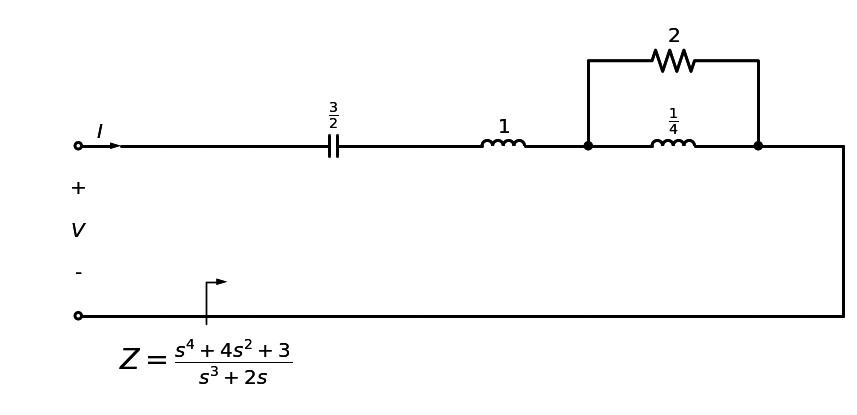

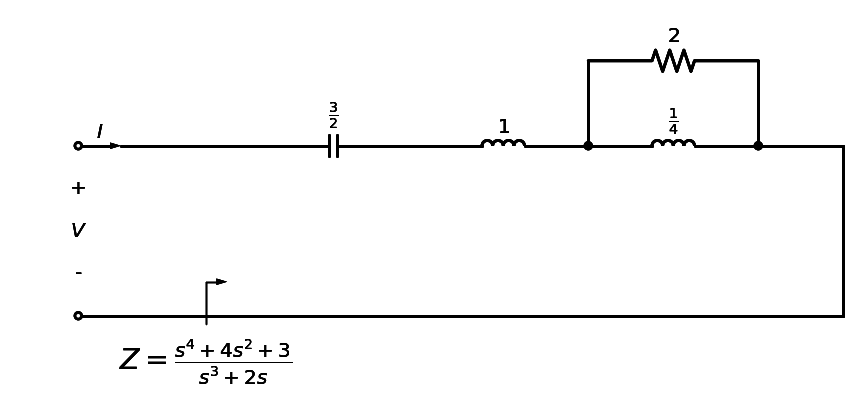

In [18]:
import sympy as sp

# Ahora importamos las funciones de PyTC2

from pytc2.sintesis_dipolo import foster
from pytc2.dibujar import dibujar_foster_serie, dibujar_foster_derivacion
from pytc2.general import print_latex#, print_subtitle, a_equal_b_latex

# Importante importar símbolos de variables 
from pytc2.general import s

# Sea la siguiente función de excitación
FF = (s**4 + 4*s**2 + 3)/(s**3 + 2*s)

k0, koo, ki_wi = foster(FF)

print(r'k_0=', k0)

print(r'K_1=', ki_wi )

print(r'k_\infty=', koo)

# Tratamos a nuestra función imitancia como una Z
dibujar_foster_serie(k0, koo, ki_wi, z_exc = FF)

**B)** Con los residuos calculados anteriormente:
$$
F(s)=Y(s)=\frac{\frac{3}{2}}{s}+s+ \frac{\frac{1}{2}s}{s^2+2}
$$

El dipolo electrico que sugiere esta ultima expresion es: un inductor de $\frac{2}{3}Hy$,en paralelo con un capacitor de $1F$,en paralelo con un tanque LC serie con $C=\frac{1}{4}F$ y $L=2$


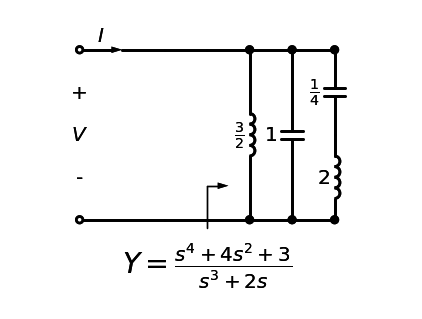

In [21]:
# Tratamos a nuestra función imitancia como una Z
dibujar_foster_derivacion(k0, koo, ki_wi, y_exc = FF)

Para el analisis en LTspice, factorizamos Z(s):
$$
Z(s)=\frac{(s^2+1)(s^2+3)}{s(s^2+2)}
$$

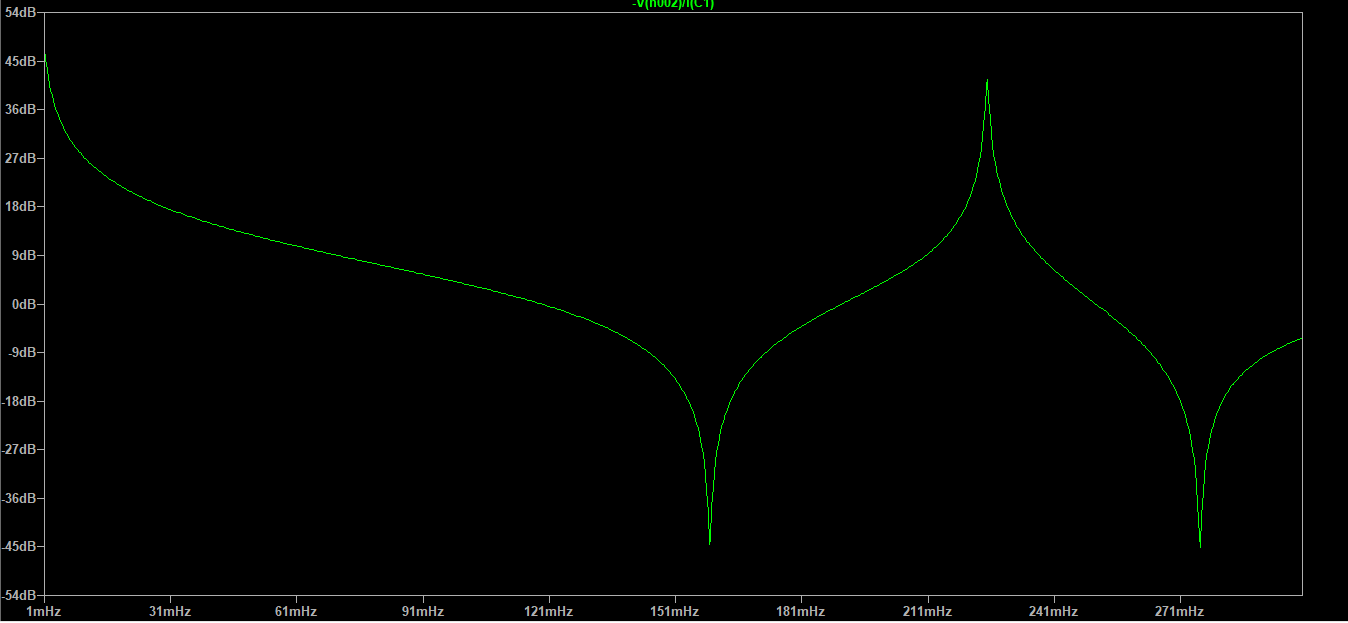

Podemos ver los dos ceros en $\frac{1}{2\pi}Hz$ y $\frac{3}{2\pi}Hz$ y los polos en $0$ y $\frac{2}{2\pi}Hz$

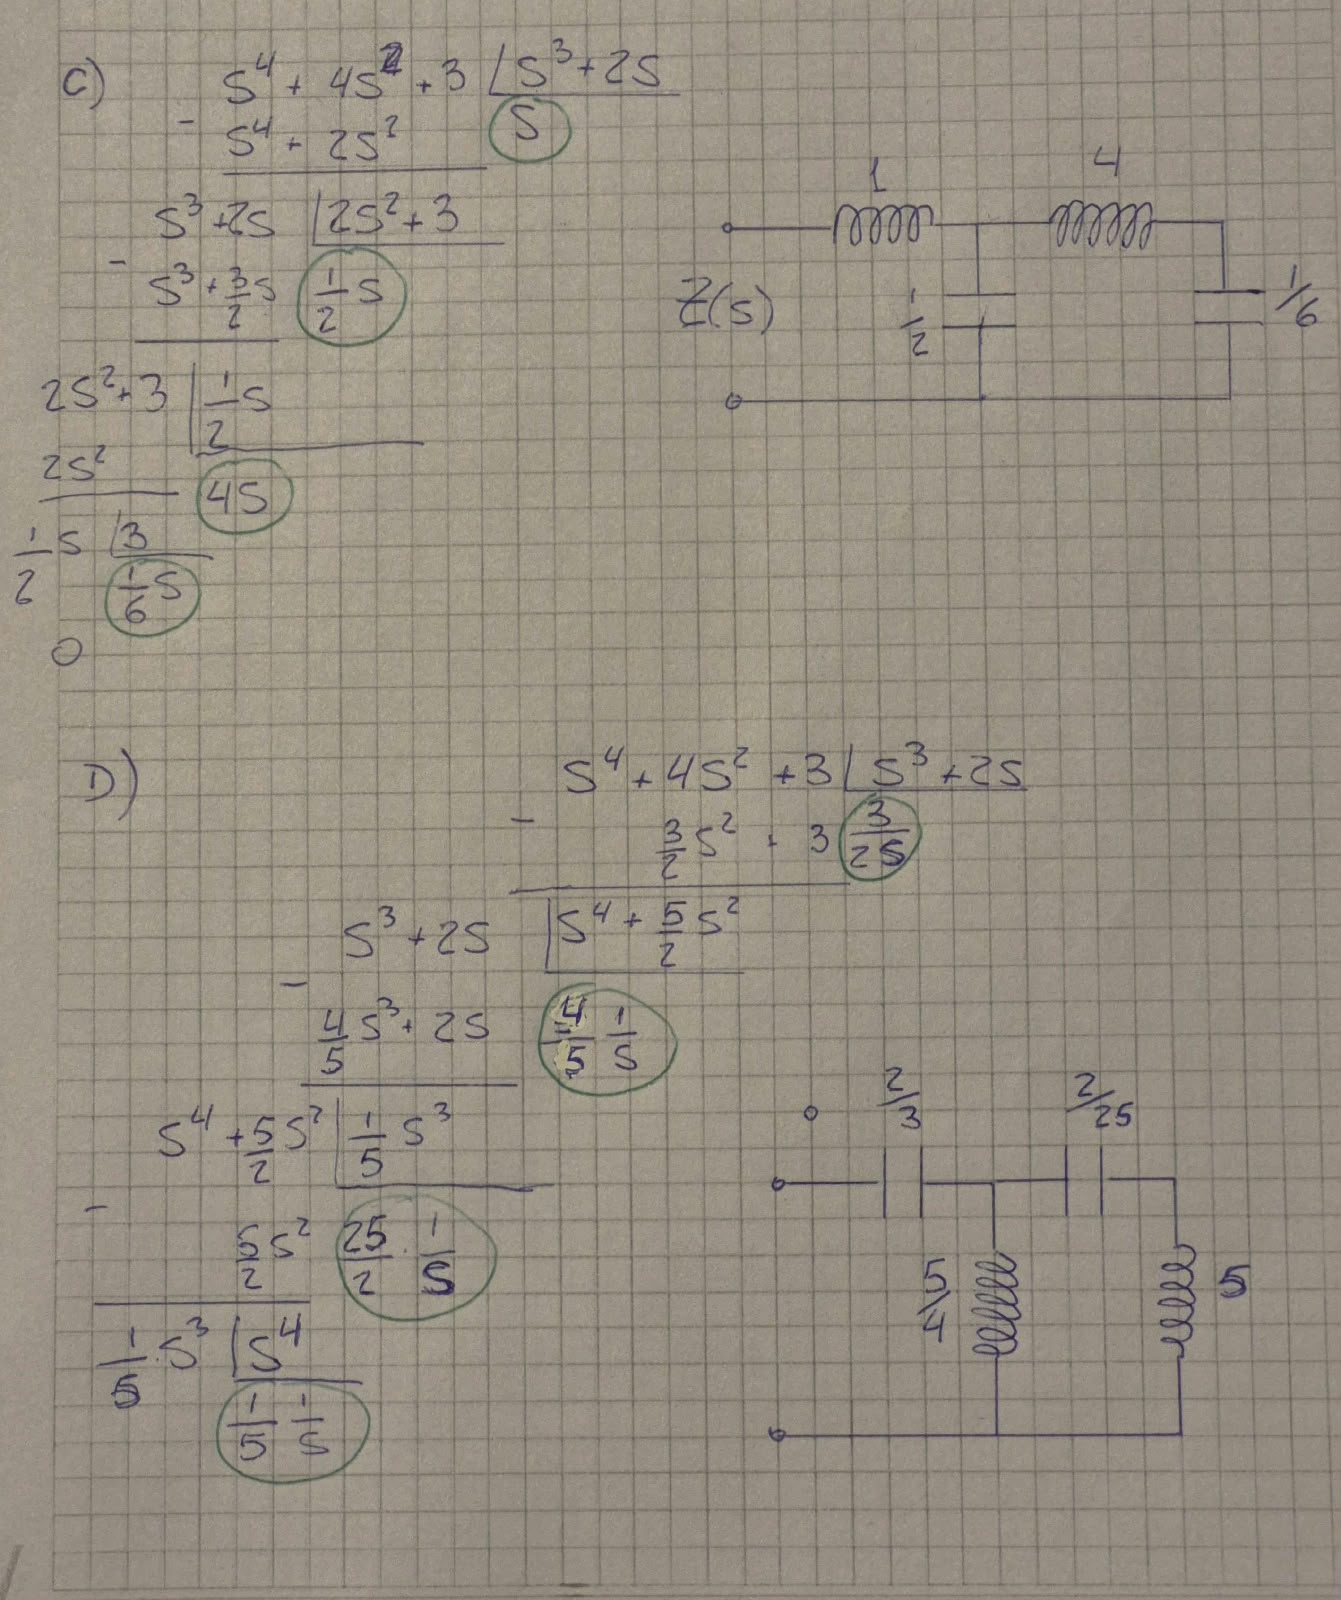

**2)** Esquematice el mapa de remociones mediante el método gráfico y halle el valor de los componentes sabiendo que satisface la función admitancia propuesta:
$$
Y(s)=\frac{s^5+18s^3+48s}{6s^4+42s^2+48}
$$

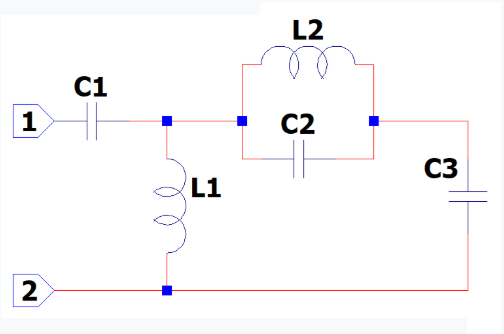

Removemos primero $C_1$:

$$
K_0=\lim_{s \to 0}sZ(s)=1 => C_1=1
$$

$$
Z_2(s)=Z(s)-Z_1(s)
$$
$$
Z_2(s)=\frac{6s^4+42s^2+48}{s^5+18s^3+48s}-\frac{1}{s}= \frac{5s^3+24s}{s^4+18s^2+48}
$$

Ahora removemos $L_1$;

$$
K_0=\lim_{s \to 0}sY(s)=2 => L_1=\frac{1}{2}
$$
$$
Y_4(s)=Y_2(s)-\frac{2}{s}
$$
$$
Y_4(s)=\frac{s^4+18s^2+48}{5s^3+24s}-\frac{2}{s}=\frac{s^3+8s}{5s^2+24}
$$

Luego, removemos $C_3$:
$$
K_0=\lim_{s \to 0}sZ(s)=3 => C_3=\frac{1}{3}
$$
$$
Z_6(s)=Z_4(s)-\frac{3}{s}
$$
$$
Z_6(s)=\frac{5s^2+24}{s^3+8s}-\frac{3}{s}=\frac{2s}{s^2+8}
$$

Lo que queda es el tanque LC, entonces,$L_2=\frac{1}{4}$y $C_2=\frac{1}{2}$
